In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("misrakahmed/vegetable-image-dataset")

print("Path to dataset files:", path)

100%|██████████| 534M/534M [00:04<00:00, 120MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/misrakahmed/vegetable-image-dataset/versions/1


In [ ]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

if tf.config.list_physical_devices('GPU'):
    print("GPU is available.")
    device_name = tf.test.gpu_device_name()
    print(f"Found GPU at: {device_name}")
else:
    print("No GPU found. Using CPU.")

TensorFlow Version: 2.20.0
Num GPUs Available:  1
GPU is available.
Found GPU at: /device:GPU:0


In [ ]:
import os

# Define image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# The dataset is located under 'Vegetable Images'
dataset_path = os.path.join(path, 'Vegetable Images')

# Create training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(dataset_path, 'train'),
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Create validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(dataset_path, 'validation'),
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Get the number of classes
num_classes = len(train_ds.class_names)
print(f"Number of classes: {num_classes}")
print(f"Class names: {train_ds.class_names}")

# Configure the dataset for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 15000 files belonging to 15 classes.
Found 3000 files belonging to 15 classes.
Number of classes: 15
Class names: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

# Load the ResNet50 model without the top (classification) layers
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Freeze the convolutional layers of ResNet50
for layer in base_model.layers:
    layer.trainable = False

# Create the model
model = Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)), # Normalize pixel values
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,281,935 (188.00 MB)

 Trainable params: 25,694,223 (98.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
EPOCHS = 20

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 129ms/step - accuracy: 0.0754 - loss: 2.7080 - val_accuracy: 0.1253 - val_loss: 2.6417
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 50s 106ms/step - accuracy: 0.0964 - loss: 2.6451 - val_accuracy: 0.1133 - val_loss: 2.5780
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 113ms/step - accuracy: 0.1137 - loss: 2.6063 - val_accuracy: 0.1683 - val_loss: 2.5222
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 111ms/step - accuracy: 0.1225 - loss: 2.5760 - val_accuracy: 0.2003 - val_loss: 2.5015
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 111ms/step - accuracy: 0.1294 - loss: 2.5492 - val_accuracy: 0.2253 - val_loss: 2.4835
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 110ms/step - accuracy: 0.1401 - loss: 2.5247 - val_accuracy: 0.2537 - val_loss: 2.4262
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 110ms/step - accuracy: 0.1367 - loss: 2.5169 - val_accuracy: 0.2517 - val_loss: 2.3954
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 110ms/step - accuracy: 0.1475 - loss: 2

In [ ]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])
print("Final Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

Final Training Accuracy: 0.16333332657814026
Final Validation Accuracy: 0.3243333399295807
Final Training Loss: 2.3891854286193848
Final Validation Loss: 2.2149829864501953


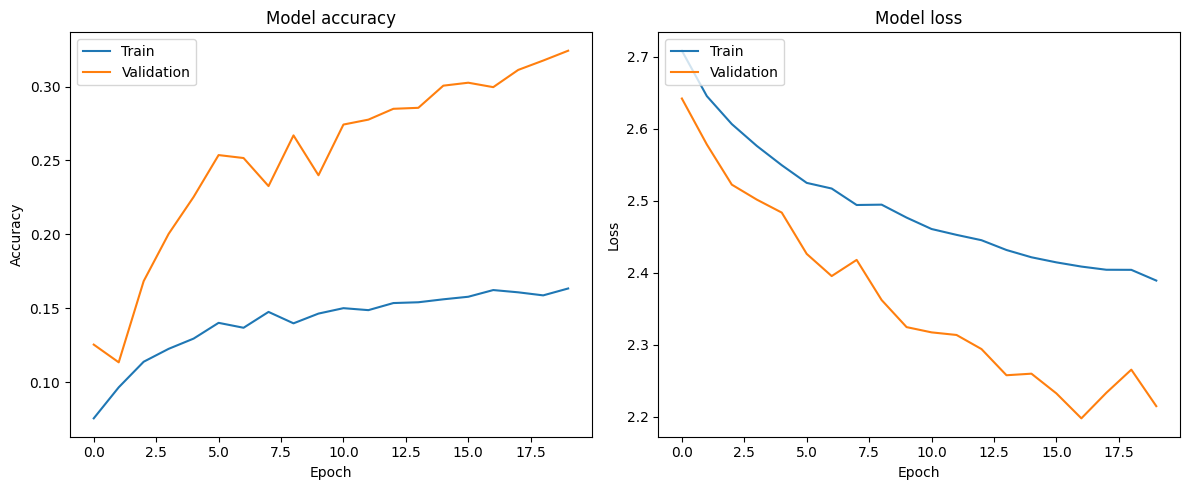

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# Re-create the model with trainable base_model for fine-tuning
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization

# Load the ResNet50 model without the top (classification) layers
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Freeze all layers in the base model initially
base_model.trainable = False

# Unfreeze the last few layers (specifically, the 'conv5_block' in ResNet50) of the base_model for fine-tuning,
# but keep BatchNormalization layers frozen.
for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False
    elif 'conv5_block' in layer.name or 'res5' in layer.name: # Unfreeze layers in the last block
        layer.trainable = True

# Create the model
model_finetuned = Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)), # Normalize pixel values
    base_model, # The base_model now has some selectively trainable layers
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile the model with an even much lower learning rate for fine-tuning
model_finetuned.compile(
    optimizer=Adam(learning_rate=0.000001), # Further reduced learning rate for more gradual fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_finetuned.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,281,935 (188.00 MB)

 Trainable params: 40,647,695 (155.06 MB)

 Non-trainable params: 8,634,240 (32.94 MB)

In [ ]:
EPOCHS_FINETUNE = 20 # Reduce epochs for fine-tuning

# Train the fine-tuned model
history_finetuned = model_finetuned.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINETUNE
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 173ms/step - accuracy: 0.1997 - loss: 2.4754 - val_accuracy: 0.3280 - val_loss: 2.2937
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 151ms/step - accuracy: 0.2793 - loss: 2.2609 - val_accuracy: 0.4273 - val_loss: 2.0336
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 70s 149ms/step - accuracy: 0.3607 - loss: 2.0249 - val_accuracy: 0.5177 - val_loss: 1.7611
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 70s 149ms/step - accuracy: 0.4287 - loss: 1.8126 - val_accuracy: 0.5700 - val_loss: 1.5440
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 70s 149ms/step - accuracy: 0.4863 - loss: 1.6293 - val_accuracy: 0.6170 - val_loss: 1.3763
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 70s 150ms/step - accuracy: 0.5361 - loss: 1.4850 - val_accuracy: 0.6667 - val_loss: 1.2380
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 70s 150ms/step - accuracy: 0.5789 - loss: 1.3617 - val_accuracy: 0.6893 - val_loss: 1.1415
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 70s 149ms/step - accuracy: 0.6097 - loss: 1

In [ ]:
print("Final Training Accuracy (Finetuned):", history_finetuned.history['accuracy'][-1])
print("Final Validation Accuracy (Finetuned):", history_finetuned.history['val_accuracy'][-1])
print("Final Training Loss (Finetuned):", history_finetuned.history['loss'][-1])
print("Final Validation Loss (Finetuned):", history_finetuned.history['val_loss'][-1])

Final Training Accuracy (Finetuned): 0.7858666777610779
Final Validation Accuracy (Finetuned): 0.831333339214325
Final Training Loss (Finetuned): 0.7112108469009399
Final Validation Loss (Finetuned): 0.5981170535087585


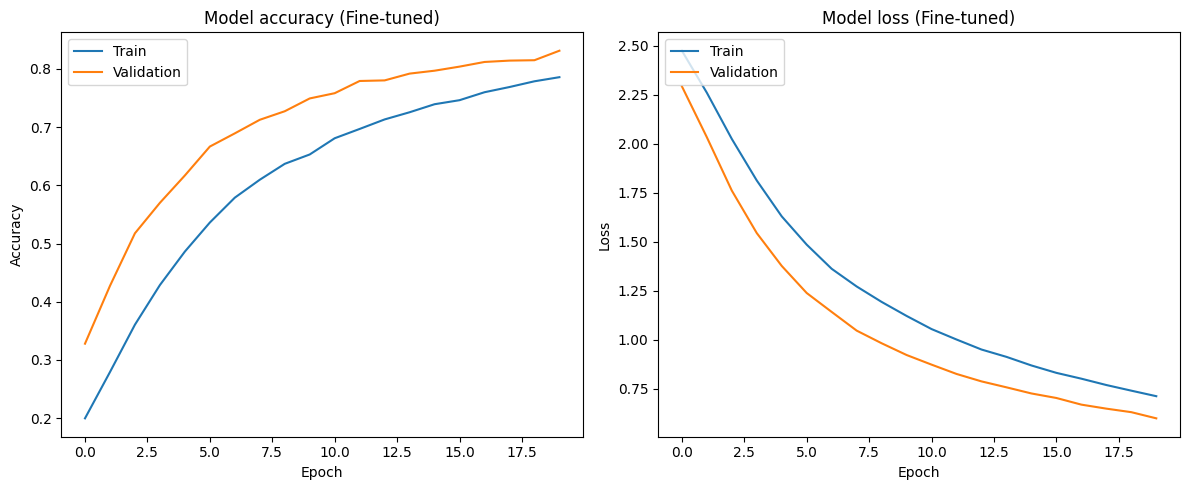

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_finetuned.history['accuracy'])
plt.plot(history_finetuned.history['val_accuracy'])
plt.title('Model accuracy (Fine-tuned)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_finetuned.history['loss'])
plt.plot(history_finetuned.history['val_loss'])
plt.title('Model loss (Fine-tuned)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()